In [1]:
import numpy as np
import pandas as pd
import os


In [2]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


In [3]:
import torchvision
print("Torchvision version:", torchvision.__version__)


Torchvision version: 0.20.1+cu121


In [4]:
!pip install -U albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 290.6/290.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 632.7/632.7 kB 28.5 MB/s eta 0:00:00
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.19
    Uninstalling albucore-0.0.19:
      Successfully uninstalled albucore-0.0.19
  Attempting uninstall: albumentations
    Found existing installation: albumentations 1.4.20
    Uninstalling albumentations-1.4.20:
      Successfully uninstalled albumentations-1.4.20


In [5]:
import torch
print(torch.version.cuda)


12.1


In [6]:
import torch
import torchvision
from torchvision import datasets,models 
from torchvision.transforms import functional as FT
from torchvision import transforms as T
from torch import nn,optim
from torch.utils.data import DataLoader,sampler,random_split,Dataset
from torch.nn import functional as F
import copy
import math
from PIL import Image
import cv2
import albumentations as A
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
#removing the warnings 
import warnings
warnings.filterwarnings("ignore")
from collections import defaultdict,deque
import datetime
import time
from tqdm import tqdm 
from torchvision.utils import draw_bounding_boxes


In [8]:
print(torch.__version__)
print(torchvision.__version__)

2.5.1+cu121
0.20.1+cu121


In [9]:
!pip install pycocotools
from pycocotools.coco import COCO

In [10]:
from albumentations.pytorch import ToTensorV2

In [11]:
def get_transforms(train=False):
    if train:
        transform = A.Compose([
            A.Resize(600, 600), # our input size can be 600px
            A.HorizontalFlip(p=0.3),
            A.VerticalFlip(p=0.3),
            A.RandomBrightnessContrast(p=0.1),
            A.ColorJitter(p=0.1),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco'))
    else:
        transform = A.Compose([
            A.Resize(600, 600), # our input size can be 600px
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco'))
    return transform

In [12]:
class AquariumDetection(datasets.VisionDataset):
    def __init__(self, root, split='train', transform=None, target_transform=None, transforms=None):
        # the 3 transform parameters are reuqired for datasets.VisionDataset
        super().__init__(root, transforms, transform, target_transform)
        self.split = split #train, valid, test
        self.coco = COCO(os.path.join(root, split, "_annotations.coco.json")) # annotatiosn stored here
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.ids = [id for id in self.ids if (len(self._load_target(id)) > 0)]
    
    def _load_image(self, id: int):
        path = self.coco.loadImgs(id)[0]["file_name"]
        image = cv2.imread(os.path.join(self.root, self.split, path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image
    def _load_target(self, id):
        return self.coco.loadAnns(self.coco.getAnnIds(id))
    
    def __getitem__(self, index):
        id = self.ids[index]
        image = self._load_image(id)
        target = self._load_target(id)
        target = copy.deepcopy(self._load_target(id))
        
        boxes = [t['bbox'] + [t['category_id']] for t in target] # required annotation format for albumentations
        if self.transforms is not None:
            transformed = self.transforms(image=image, bboxes=boxes)
        
        image = transformed['image']
        boxes = transformed['bboxes']
        
        new_boxes = [] # convert from xywh to xyxy
        for box in boxes:
            xmin = box[0]
            xmax = xmin + box[2]
            ymin = box[1]
            ymax = ymin + box[3]
            new_boxes.append([xmin, ymin, xmax, ymax])
        
        boxes = torch.tensor(new_boxes, dtype=torch.float32)
        
        targ = {} # here is our transformed target
        targ['boxes'] = boxes
        targ['labels'] = torch.tensor([t['category_id'] for t in target], dtype=torch.int64)
        targ['image_id'] = torch.tensor([t['image_id'] for t in target])
        targ['area'] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]) # we have a different area
        targ['iscrowd'] = torch.tensor([t['iscrowd'] for t in target], dtype=torch.int64)
        return image.div(255), targ # scale images
    def __len__(self):
        return len(self.ids)

In [13]:
dataset_path ="/kaggle/input/aquarium-dataset/Aquarium Combined"

In [14]:
#load classes
import os
coco = COCO(os.path.join(dataset_path, "train", "_annotations.coco.json"))
categories = coco.cats
n_classes = len(categories.keys())
categories

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


{0: {'id': 0, 'name': 'creatures', 'supercategory': 'none'},
 1: {'id': 1, 'name': 'fish', 'supercategory': 'creatures'},
 2: {'id': 2, 'name': 'jellyfish', 'supercategory': 'creatures'},
 3: {'id': 3, 'name': 'penguin', 'supercategory': 'creatures'},
 4: {'id': 4, 'name': 'puffin', 'supercategory': 'creatures'},
 5: {'id': 5, 'name': 'shark', 'supercategory': 'creatures'},
 6: {'id': 6, 'name': 'starfish', 'supercategory': 'creatures'},
 7: {'id': 7, 'name': 'stingray', 'supercategory': 'creatures'}}

In [15]:
classes = [i[1]['name'] for i in categories.items()]
classes

['creatures',
 'fish',
 'jellyfish',
 'penguin',
 'puffin',
 'shark',
 'starfish',
 'stingray']

In [16]:
train_dataset = AquariumDetection(root=dataset_path, transforms=get_transforms(True))


loading annotations into memory...
Done (t=0.19s)
creating index...
index created!


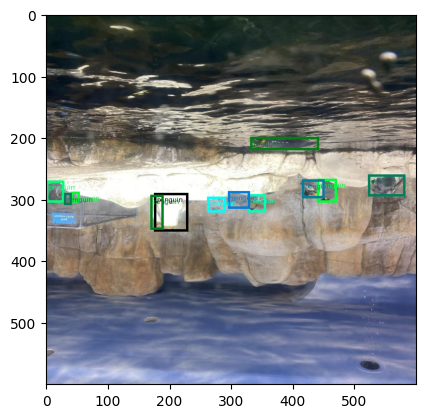

In [17]:
sample = train_dataset[9]
img_int = torch.tensor(sample[0] * 255, dtype=torch.uint8)
plt.imshow(draw_bounding_boxes(
    img_int, sample[1]['boxes'], [classes[i] for i in sample[1]['labels']], width=4
).permute(1, 2, 0))

In [18]:
len(train_dataset)

447

In [19]:
# lets load the faster rcnn model
model = models.detection.fasterrcnn_mobilenet_v3_large_fpn(pretrained=True)
in_features = model.roi_heads.box_predictor.cls_score.in_features # we need to change the head
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, n_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_fpn-fb6a3cc7.pth
100%|██████████| 74.2M/74.2M [00:00<00:00, 184MB/s]


In [20]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [21]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=4, collate_fn=collate_fn)

In [22]:
images,targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k:v for k, v in t.items()} for t in targets]
output = model(images, targets) # just make sure this runs without error

In [23]:
device = torch.device("cuda") # use GPU to train

In [24]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118


Looking in indexes: https://download.pytorch.org/whl/cu118


In [25]:
import torch
print("Is CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())


Is CUDA available: True
CUDA version: 12.1
Device count: 2


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)


In [27]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.01, momentum=0.9, nesterov=True, weight_decay=1e-4)
# lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[16, 22], gamma=0.1) # lr scheduler

In [28]:
import sys


In [29]:
def train_one_epoch(model, optimizer, loader, device, epoch):
    model.to(device)
    model.train()
    
#     lr_scheduler = None
#     if epoch == 0:
#         warmup_factor = 1.0 / 1000 # do lr warmup
#         warmup_iters = min(1000, len(loader) - 1)
        
#         lr_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor = warmup_factor, total_iters=warmup_iters)
    
    all_losses = []
    all_losses_dict = []
    
    for images, targets in tqdm(loader):
        images = list(image.to(device) for image in images)
        targets = [{k: torch.tensor(v).to(device) for k, v in t.items()} for t in targets]
        
        loss_dict = model(images, targets) # the model computes the loss automatically if we pass in targets
        losses = sum(loss for loss in loss_dict.values())
        loss_dict_append = {k: v.item() for k, v in loss_dict.items()}
        loss_value = losses.item()
        
        all_losses.append(loss_value)
        all_losses_dict.append(loss_dict_append)
        
        if not math.isfinite(loss_value):
            print(f"Loss is {loss_value}, stopping trainig") # train if loss becomes infinity
            print(loss_dict)
            sys.exit(1)
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
#         if lr_scheduler is not None:
#             lr_scheduler.step() # 
        
    all_losses_dict = pd.DataFrame(all_losses_dict) # for printing
    print("Epoch {}, lr: {:.6f}, loss: {:.6f}, loss_classifier: {:.6f}, loss_box: {:.6f}, loss_rpn_box: {:.6f}, loss_object: {:.6f}".format(
        epoch, optimizer.param_groups[0]['lr'], np.mean(all_losses),
        all_losses_dict['loss_classifier'].mean(),
        all_losses_dict['loss_box_reg'].mean(),
        all_losses_dict['loss_rpn_box_reg'].mean(),
        all_losses_dict['loss_objectness'].mean()
    ))

In [30]:
import pandas as pd
import numpy as np

num_epochs=10

for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, train_loader, device, epoch)
#     lr_scheduler.step()

100%|██████████| 112/112 [00:20<00:00,  5.47it/s]


Epoch 0, lr: 0.010000, loss: 0.973150, loss_classifier: 0.452955, loss_box: 0.394740, loss_rpn_box: 0.031996, loss_object: 0.093460


100%|██████████| 112/112 [00:18<00:00,  6.16it/s]


Epoch 1, lr: 0.010000, loss: 0.757491, loss_classifier: 0.338113, loss_box: 0.334664, loss_rpn_box: 0.027883, loss_object: 0.056831


100%|██████████| 112/112 [00:18<00:00,  6.18it/s]


...

Epoch 7, lr: 0.010000, loss: 0.631615, loss_classifier: 0.234193, loss_box: 0.347835, loss_rpn_box: 0.021799, loss_object: 0.027789


100%|██████████| 112/112 [00:18<00:00,  5.98it/s]


Epoch 8, lr: 0.010000, loss: 0.631654, loss_classifier: 0.235780, loss_box: 0.349580, loss_rpn_box: 0.021323, loss_object: 0.024971


100%|██████████| 112/112 [00:18<00:00,  6.04it/s]

Epoch 9, lr: 0.010000, loss: 0.634720, loss_classifier: 0.231980, loss_box: 0.358408, loss_rpn_box: 0.020792, loss_object: 0.023540


In [31]:
# we will watch first epoich to ensure no errrors
# while it is training, lets write code to see the models predictions. lets try again
model.eval()
torch.cuda.empty_cache()

In [32]:
test_dataset = AquariumDetection(root=dataset_path, split="test", transforms=get_transforms(False))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [33]:
img, _ = test_dataset[9]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

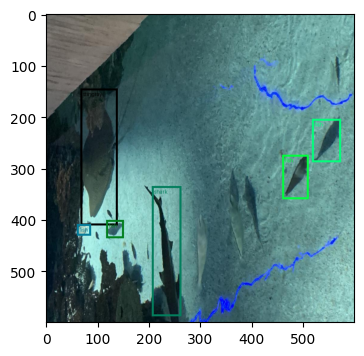

In [34]:
fig = plt.figure(figsize=(20, 4))
plt.imshow(draw_bounding_boxes(img_int,
    pred['boxes'][pred['scores'] > 0.8],
    [classes[i] for i in pred['labels'][pred['scores'] > 0.8].tolist()], width=4
).permute(1, 2, 0))

In [35]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 922.2/922.2 kB 18.2 MB/s eta 0:00:00


In [36]:
from ultralytics import YOLO

# Load the pre-trained YOLOv5 model
model = YOLO("yolov5s.pt")

# Start training
results = model.train(data="/kaggle/input/yolov5-dataset2/Aquarium Combined.v2-raw-1024.yolov5pytorch/data.yaml",  # Path to your data.yaml file
                      imgsz=416,                   # Image size
                      epochs=7,                   # Number of epochs
                      batch=16,                    # Batch size
                      device=0)                    # Set to 'cpu' if not using GPU


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.



100%|██████████| 17.7M/17.7M [00:00<00:00, 142MB/s] 


Ultralytics 8.3.82 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov5s.pt, data=/kaggle/input/yolov5-dataset2/Aquarium Combined.v2-raw-1024.yolov5pytorch/data.yaml, epochs=7, time=None, patience=100, batch=16, imgsz=416, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_cro

100%|██████████| 755k/755k [00:00<00:00, 26.7MB/s]


Overriding model.yaml nc=80 with nc=7

                   from  n    params  module                                       arguments                     
  0                  -1  1      3520  ultralytics.nn.modules.conv.Conv             [3, 32, 6, 2, 2]              
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     18816  ultralytics.nn.modules.block.C3              [64, 64, 1]                   
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    115712  ultralytics.nn.modules.block.C3              [128, 128, 2]                 
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  3    625152  ultralytics.nn.modules.block.C3              [256, 256, 3]                 
  7                  -1  1   1180672  ultralytics

...

        7/7      1.87G      1.465      1.399      1.163         29        416: 100%|██████████| 21/21 [00:02<00:00,  7.57it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:00<00:00,  6.35it/s]

                   all        114        731      0.543      0.498      0.489      0.285



7 epochs completed in 0.010 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 18.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 18.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.82 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)
YOLOv5s summary (fused): 84 layers, 9,114,245 parameters, 0 gradients, 23.8 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  2.26it/s]


                   all        114        731      0.546      0.499      0.489      0.285
                  fish         57        371       0.63       0.49      0.528      0.276
             jellyfish          9        155      0.905      0.428      0.615      0.351
               penguin          4         29     0.0809      0.379     0.0741     0.0315
                puffin         13         72       0.47      0.259      0.256      0.108
                 shark         23         47       0.54       0.45      0.483      0.257
              starfish         16         25      0.778      0.702       0.73      0.521
              stingray         22         32      0.419      0.781      0.741      0.453
Speed: 0.1ms preprocess, 2.0ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/train


In [37]:
# Test on a sample image (replace with your image path)
#results = model.predict(source="/kaggle/input/yolov5-model-dataset/Aquarium Combined.v2-raw-1024.yolov5pytorch/test/images/IMG_2387_jpeg_jpg.rf.09b38bacfab0922a3a6b66480f01b719.jpg", save=True)
#results = model.predict(source="/kaggle/input/yolov5-model-dataset/Aquarium Combined.v2-raw-1024.yolov5pytorch/test/images/IMG_2423_jpeg_jpg.rf.1c0901882e71d5ebd26f036f4e22da65.jpg", save=True)
results = model.predict(source="/kaggle/input/yolov5-dataset2/Aquarium Combined.v2-raw-1024.yolov5pytorch/test/images/IMG_2387_jpeg_jpg.rf.09b38bacfab0922a3a6b66480f01b719.jpg", save=True)
#results = model.predict(source="/kaggle/input/yolov5-model-dataset/Aquarium Combined.v2-raw-1024.yolov5pytorch/test/images/IMG_2387_jpeg_jpg.rf.09b38bacfab0922a3a6b66480f01b719.jpg", save=True)
#results = model.predict(source="/kaggle/input/yolov5-model-dataset/Aquarium Combined.v2-raw-1024.yolov5pytorch/test/images/IMG_2387_jpeg_jpg.rf.09b38bacfab0922a3a6b66480f01b719.jpg", save=True)
#results = model.predict(source="/kaggle/input/yolov5-model-dataset/Aquarium Combined.v2-raw-1024.yolov5pytorch/test/images/IMG_2387_jpeg_jpg.rf.09b38bacfab0922a3a6b66480f01b719.jpg", save=True)


# Results will be saved with bounding boxes drawn on detected objects
print(results)



image 1/1 /kaggle/input/yolov5-dataset2/Aquarium Combined.v2-raw-1024.yolov5pytorch/test/images/IMG_2387_jpeg_jpg.rf.09b38bacfab0922a3a6b66480f01b719.jpg: 416x320 1 starfish, 1 stingray, 39.6ms
Speed: 1.3ms preprocess, 39.6ms inference, 1.8ms postprocess per image at shape (1, 3, 416, 320)
Results saved to runs/detect/train2
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'fish', 1: 'jellyfish', 2: 'penguin', 3: 'puffin', 4: 'shark', 5: 'starfish', 6: 'stingray'}
obb: None
orig_img: array([[[102,  48,  31],
        [ 99,  45,  28],
        [ 94,  42,  26],
        ...,
        [ 98,  38,  26],
        [ 98,  38,  26],
        [ 97,  37,  25]],

       [[104,  50,  33],
        [ 99,  45,  28],
        [ 96,  41,  26],
        ...,
        [ 93,  33,  21],
        [ 95,  35,  23],
        [ 96,  36,  24]],

       [[109,  52,  37],
        [100,  45,  30],
        [ 96,  41,  28],
       

In [38]:
!pip install -U ipywidgets

Using results from: /kaggle/working/runs/detect/train2


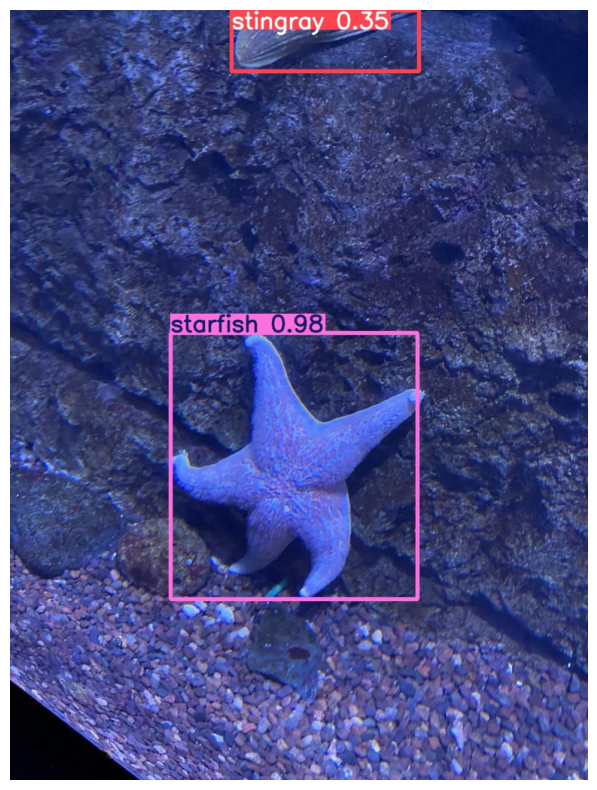

In [39]:
base_folder = "/kaggle/working/runs/detect"
if os.path.exists(base_folder):
    subfolders = sorted([f for f in os.listdir(base_folder) if f.startswith("train")], reverse=True)
    latest_run = os.path.join(base_folder, subfolders[0]) if subfolders else None

    if latest_run and os.path.exists(latest_run):
        print("Using results from:", latest_run)
        output_images = [f for f in os.listdir(latest_run) if f.endswith(".jpg")]
        for img_file in output_images:
            img_path = os.path.join(latest_run, img_file)
            img = Image.open(img_path)
            plt.figure(figsize=(10, 10))
            plt.imshow(img)
            plt.axis("off")
            plt.show()
    else:
        print("No training runs found.")
else:
    print("Base directory does not exist.")
